# Healthcare Claims — Part II: Modeling Cost on the Log Scale

Continuation of `healthcare_encounter_cost_analysis.ipynb`. There we modeled encounter cost in dollars and ended with

$$\text{TotalCost} \sim \text{LengthOfStay} + \text{NumRevenueCodes} , \qquad R^2 = 0.681,$$

but flagged a caveat: the residuals are heavily right-skewed and heteroskedastic, which strains the assumptions behind the t-tests and intervals. Here we address that directly by **log-transforming the response**.

**Contents**

6. Diagnostics of the dollar-scale model — why a log?
7. The log-response model: fit and interpretation
8. Residual diagnostics revisited
9. Back to dollars: predictions and trade-offs


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as st

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

# Rebuild the encounter table and the Part I models
df = pd.read_csv("https://github.com/thousandoaks/Python4DS-I/raw/main/datasets/HealthcareDataset_PublicRelease.csv",sep=',',parse_dates=['StartDate','EndDate','BirthDate'])
 




enc = (df.groupby('MedicalClaim')
         .agg(TotalCost=('TotalExpenses', 'sum'),
              NumRevenueCodes=('RevenueCode', 'nunique'),
              StartDate=('StartDate', 'min'), EndDate=('EndDate', 'max'))
         .reset_index())
enc['LengthOfStay'] = (enc.EndDate - enc.StartDate).dt.days

Xq = enc[['LengthOfStay', 'NumRevenueCodes']].copy()
Xq['NumRevenueCodes^2'] = enc.NumRevenueCodes ** 2
dollar = sm.OLS(enc.TotalCost, sm.add_constant(Xq)).fit()   # Part I final model
print(f'Part I dollar-scale model: R2 = {dollar.rsquared:.3f}  (n = {len(enc):,})')

Part I dollar-scale model: R2 = 0.734  (n = 3,361)


## 6. Diagnostics of the dollar-scale model — why a log?

OLS inference assumes errors with constant variance and (for exact t/F distributions) approximate normality. Let's look at the residuals of the Part I model.

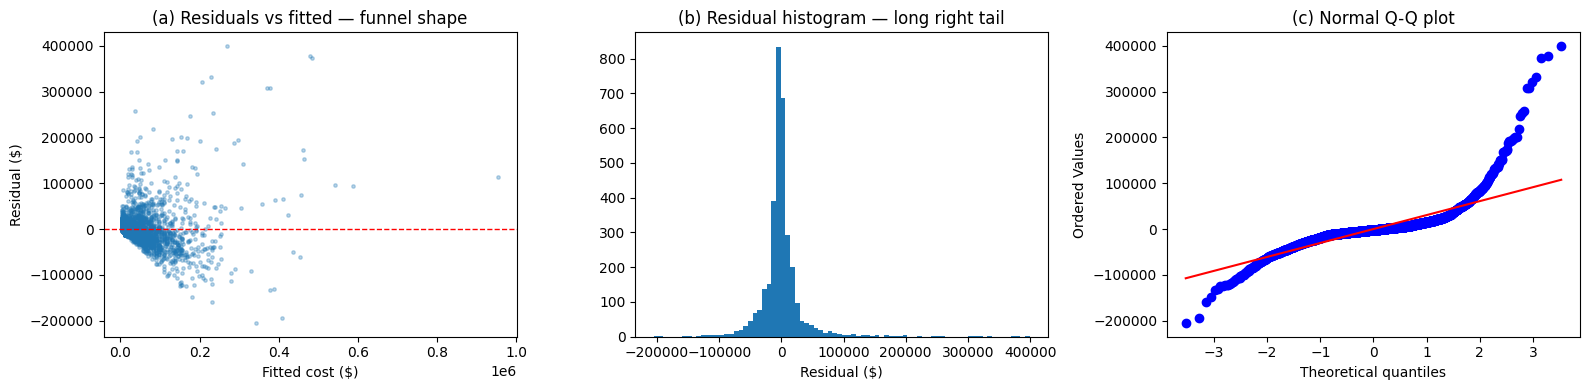

Residual skewness      : 2.95
Breusch-Pagan p-value  : 2.01e-141   (H0: constant variance)


In [2]:
resid_d = dollar.resid

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.scatter(dollar.fittedvalues, resid_d, s=6, alpha=0.3)
ax.axhline(0, color='r', ls='--', lw=1)
ax.set_xlabel('Fitted cost ($)'); ax.set_ylabel('Residual ($)')
ax.set_title('(a) Residuals vs fitted — funnel shape')

ax = axes[1]
ax.hist(resid_d, bins=80)
ax.set_xlabel('Residual ($)'); ax.set_title('(b) Residual histogram — long right tail')

ax = axes[2]
st.probplot(resid_d, plot=ax)
ax.set_title('(c) Normal Q-Q plot')

plt.tight_layout(); plt.show()

from statsmodels.stats.diagnostic import het_breuschpagan
bp_p = het_breuschpagan(resid_d, sm.add_constant(Xq))[1]
print(f'Residual skewness      : {st.skew(resid_d):.2f}')
print(f'Breusch-Pagan p-value  : {bp_p:.3g}   (H0: constant variance)')

**Diagnosis.** All three assumptions fail visibly: the residual spread grows with the fitted value (funnel → heteroskedasticity, Breusch–Pagan $p \approx 10^{-141}$), the distribution has a long right tail (skewness ≈ 3), and the Q-Q plot bends far off the line. Costs behave **multiplicatively** — big encounters have big errors. The standard remedy for a positive, right-skewed, multiplicative response is to model $\log(\text{cost})$.

## 7. The log-response model

$$\log(\text{TotalCost}_i) = \beta_0 + \beta_1\,\text{LengthOfStay}_i + \beta_2\,\text{NumRevenueCodes}_i + \varepsilon_i$$

The predictors stay untransformed; only the response is logged. Coefficients now measure **relative (percentage) effects**: a one-unit increase in $x_j$ multiplies expected cost by $e^{\beta_j}$.

In [3]:
enc['LogCost'] = np.log(enc.TotalCost)
Xl = sm.add_constant(enc[['LengthOfStay', 'NumRevenueCodes']])
logm = sm.OLS(enc.LogCost, Xl).fit()

res = pd.concat([logm.params, logm.bse, logm.tvalues, logm.pvalues, logm.conf_int()], axis=1)
res.columns = ['coef', 'std err', 't', 'p-value', 'CI 2.5%', 'CI 97.5%']
res['% effect'] = (np.exp(res.coef) - 1) * 100
res['% CI low'] = (np.exp(res['CI 2.5%']) - 1) * 100
res['% CI high'] = (np.exp(res['CI 97.5%']) - 1) * 100

print(f'R-squared          = {logm.rsquared:.3f}   (on the log scale)')
print(f'Adjusted R-squared = {logm.rsquared_adj:.3f}')
print(f'F = {logm.fvalue:,.0f}   (p = {logm.f_pvalue:.3g})')
res.round(4)

R-squared          = 0.759   (on the log scale)
Adjusted R-squared = 0.758
F = 5,277   (p = 0)


,coef,std err,t,p-value,CI 2.5%,CI 97.5%,% effect,% CI low,% CI high
const,7.8907,0.0235,336.1547,0.0000,7.8447,7.9367,"267,126.0538","255,106.0914","279,712.1448"
LengthOfStay,0.0142,0.0033,4.3719,0.0000,0.0078,0.0206,1.4319,0.7872,2.0807
NumRevenueCodes,0.1508,0.0020,75.9924,0.0000,0.1469,0.1547,16.2805,15.8289,16.7340


**Interpretation.** The model explains $R^2 \approx 0.76$ of the variance of *log* cost (not directly comparable with the dollar-scale $R^2$). Both predictors are highly significant:

* **`NumRevenueCodes`**: $\hat\beta = 0.1508$ ($t = 76.0$, $p \approx 0$) → each additional distinct service category **multiplies** expected cost by $e^{0.1508} \approx 1.163$, i.e. **+16.3%** (95% CI [+15.8%, +16.7%]). This is now the dominant driver: compounding +16% per category *is* the accelerating-cost pattern that required a quadratic on the dollar scale — the log absorbs it naturally.
* **`LengthOfStay`**: $\hat\beta = 0.0142$ ($t = 4.4$, $p \approx 10^{-5}$) → each extra day adds about **+1.4%** (95% CI [+0.8%, +2.1%]). Its modest role here (vs. dominant on the dollar scale) says days matter most for *expensive* encounters: an additive \$8k/day is a large share of a \$20k encounter but a small *percentage* of a \$200k one.
* **Intercept**: $e^{7.89} \approx \$2{,}670$ — the baseline cost of a same-day encounter with one service category (a meaningful anchor now, unlike the negative intercepts on the dollar scale).

The two scales answer different questions — *dollars per day* versus *percent per day* — and both are legitimate; the log scale simply matches how this response actually varies.

## 8. Residual diagnostics revisited

Same three plots as Section 6, now for the log model.

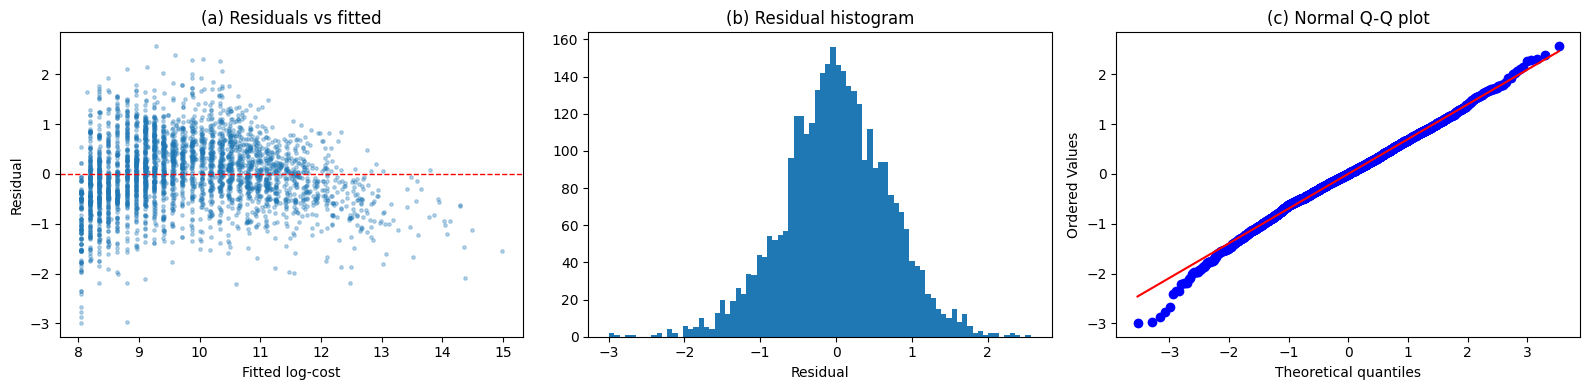

Residual skewness      : -0.15   (dollar model: 2.95)
Breusch-Pagan p-value  : 5.77e-10


In [4]:
resid_l = logm.resid

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.scatter(logm.fittedvalues, resid_l, s=6, alpha=0.3)
ax.axhline(0, color='r', ls='--', lw=1)
ax.set_xlabel('Fitted log-cost'); ax.set_ylabel('Residual')
ax.set_title('(a) Residuals vs fitted')

ax = axes[1]
ax.hist(resid_l, bins=80)
ax.set_xlabel('Residual'); ax.set_title('(b) Residual histogram')

ax = axes[2]
st.probplot(resid_l, plot=ax)
ax.set_title('(c) Normal Q-Q plot')

plt.tight_layout(); plt.show()

bp_p = het_breuschpagan(resid_l, Xl)[1]
print(f'Residual skewness      : {st.skew(resid_l):.2f}   (dollar model: {st.skew(dollar.resid):.2f})')
print(f'Breusch-Pagan p-value  : {bp_p:.3g}')

**Transformation succeeds.** The residual cloud is now a homogeneous band, the histogram is nearly symmetric (skewness **−0.15** versus **2.95** before), and the Q-Q plot hugs the line except in the extreme tails. With $n = 3361$ formal tests still reject exact normality/homoskedasticity, but the violations are now mild — the t-statistics, p-values and confidence intervals of Section 7 rest on solid ground, unlike those of the dollar-scale model.


**Conclusion.** Was the log worth it? For **inference, yes**: it is the model whose assumptions actually hold — its p-values and confidence intervals are trustworthy, its coefficients (+16.3% per service category, +1.4% per day) are interpretable and stable, and it removes the need for the quadratic term. For **predicting total spending of the most expensive cases**, the dollar-scale model of Part I remains competitive. Which to prefer depends on the question: *understanding cost drivers* → log model; *forecasting aggregate dollars* → dollar model (or a GLM with log link, which does both — a natural next step).